<a href="https://colab.research.google.com/github/drmistretta/PredictCollege/blob/main/Descriptive_Region_and_College.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


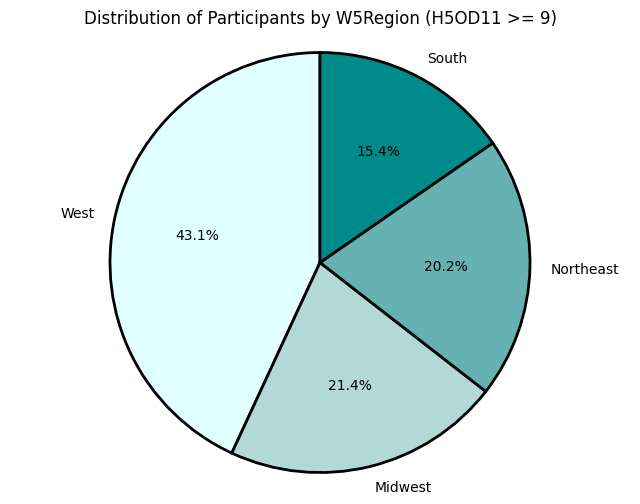

+------------+---------+--------------+
| W5REGION   |   Count |   Percentage |
+============+=========+==============+
| 4          |     881 |      43.1018 |
+------------+---------+--------------+
| 2          |     437 |      21.3796 |
+------------+---------+--------------+
| 1          |     412 |      20.1566 |
+------------+---------+--------------+
| 3          |     314 |      15.362  |
+------------+---------+--------------+
| Total      |    2044 |     100      |
+------------+---------+--------------+
Total samples in the original dataset: 4196
Number of samples eliminated (W5REGION = 98 or 99): 342
Adjusted number of samples: 3854
Percentage of College Graduates of Adjusted Sample: 53.03580695381422


In [ ]:
# Run the shell command to install the tabulate package into this Python environment
""" Three quotation marks at the beginning and end of a long string are used to
    create a multi-line string or a long comment.

   Programming note: explanation of a !pip command:
   1. A terminal is a default command-line interface on your computer. It allows the
      programmer to interact with the operating system of their computer by typing text
      commands. On a Linux or MacOS system, the application is named Terminal. On a
      Windows system, the application is named Command Prompt (CMD).
   2. A shell command is typically run in a terminal or command prompt.
   3. The ! symbol tells Colab to run a shell command within your Colab or Jupyter
      notebook.
   4. pip is the Python package used to install and manage Python libraries.
   5. install is the command used to install a package.
   6. tabulate is the package we want to install.

"""

!pip install tabulate
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate

# Load the dataset
df = pd.read_csv('/content/drive/Shared drives/Dr. Sharon Mistretta/Add Health/Predict_College/data_with_birth_year.csv')

# Convert H5OD11 to an integer
df['H5OD11'] = pd.to_numeric(df['H5OD11'], errors='coerce').fillna(0).astype(int)

# Filter the data for participants who achieved a value of H5OD11 greater than 9
filtered_df = df[df['H5OD11'] >= 9]

# Eliminate the regions 98 and 99
filtered_df = filtered_df[~filtered_df['W5REGION'].isin([98, 99])]

# Calculate the counts for each W5REGION
region_counts = filtered_df['W5REGION'].value_counts()

# Create a mapping for region names
region_labels = {
    1: 'Northeast',
    2: 'Midwest',
    3: 'South',
    4: 'West'
}

# Get the corresponding region names for the pie chart labels
labels = [region_labels.get(region, str(region)) for region in region_counts.index]

# Create the pie chart
colors = ['#e0ffff', '#b2d8d8', '#66b2b2', '#008b8b']  # Graduated light to dark cyan
plt.figure(figsize=(8, 6))
plt.pie(region_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors,wedgeprops={'edgecolor': 'black', 'linewidth': 2})
plt.title('Distribution of Participants by W5Region (H5OD11 >= 9)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Create a DataFrame from the region counts for display
region_counts_df = region_counts.reset_index()
region_counts_df.columns = ['W5REGION', 'Count']

# Calculate the percentage for each region
region_counts_df['Percentage'] = (region_counts_df['Count'] / region_counts_df['Count'].sum()) * 100

# Calculate the total count for regions 1 through 4
total_count_regions_1_to_4 = region_counts_df['Count'].sum()

# Add a row for the total count to the table
total_row = pd.DataFrame({'W5REGION': ['Total'], 'Count': [total_count_regions_1_to_4], 'Percentage': [100]})
region_counts_df = pd.concat([region_counts_df, total_row], ignore_index=True)

# Display the updated table with region counts, percentages, and total count
# print(region_counts_df)

print(tabulate(region_counts_df, headers='keys', tablefmt='grid', showindex=False))

# Calculate the total number of samples in the original dataset
total_samples = len(df)

# Calculate the number of samples eliminated (with W5REGION equal to 98 or 99)
eliminated_samples = len(df[df['W5REGION'].isin([98, 99])])
adjusted_samples = total_samples - eliminated_samples
total_percentage = (total_count_regions_1_to_4 / adjusted_samples) * 100

# Print the number of total samples and eliminated samples
print(f'Total samples in the original dataset: {total_samples}')
print(f'Number of samples eliminated (W5REGION = 98 or 99): {eliminated_samples}')
print(f'Adjusted number of samples: {adjusted_samples}')
print(f'Percentage of College Graduates of Adjusted Sample: {total_percentage}')
